What You're Aiming For
In this checkpoint, we are going to work on the 'Credit Card Dataset for Clustering' dataset provided by Kaggle.

Dataset description : This dataset was derived and simplified for learning purposes. It includes usage behaviour of about 9000 active credit card holders during 6 months period. This case requires to develop a customer segmentation to define marketing strategy.

➡️ Dataset link 

https://i.imgur.com/gAT5gVg.jpg

Columns explanation : 

CUST_ID: Identification of Credit Card holder (Categorical)
BALANCE_FREQUENCY: How frequently the Balance is updated, score between 0 and 1 (1 = frequently updated, 0 = not frequently updated)
PURCHASES: Amount of purchases made from account 
CASH_ADVANCE: Cash in advance given by the user
CREDIT_LIMIT: Limit of Credit Card for user 
PAYMENTS: Amount of Payment done by user 

Instructions
Import you data and perform basic data exploration phase
Perform the necessary data preparation steps ( Corrupted and missing values handling, data encoding, outliers handling ... )
Perform hierarchical clustering to identify the inherent groupings within your data. Then, plot the clusters. (use only 2 features. For example, try to cluster the customer base with respect to 'PURCHASES' and 'credit limit')
Perform partitional clustering using the K-means algorithm. Then, plot the clusters
Find the best k value and plot the clusters again.
Interpret the results

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch
from sklearn.cluster import AgglomerativeClustering
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Credit_card_dataset.csv")  # Use your actual file name

print(df.head())
print(df.info())
print(df.describe())


  CUST_ID  BALANCE_FREQUENCY  PURCHASES     PAYMENTS  CREDIT_LIMIT  \
0  C10001           0.818182      95.40   201.802084        1000.0   
1  C10002           0.909091       0.00  4103.032597        7000.0   
2  C10003           1.000000     773.17   622.066742        7500.0   
3  C10004           0.636364    1499.00     0.000000        7500.0   
4  C10005           1.000000      16.00   678.334763        1200.0   

   CASH_ADVANCE  
0      0.000000  
1   6442.945483  
2      0.000000  
3    205.788017  
4      0.000000  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CUST_ID            8950 non-null   object 
 1   BALANCE_FREQUENCY  8950 non-null   float64
 2   PURCHASES          8950 non-null   float64
 3   PAYMENTS           8950 non-null   float64
 4   CREDIT_LIMIT       8949 non-null   float64
 5   CASH_ADVANCE       8950 

In [3]:
# Drop CUST_ID (not needed for clustering)
df.drop(columns=['CUST_ID'], inplace=True)

# Handle missing values
df.dropna(inplace=True)

# Scale the data
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)


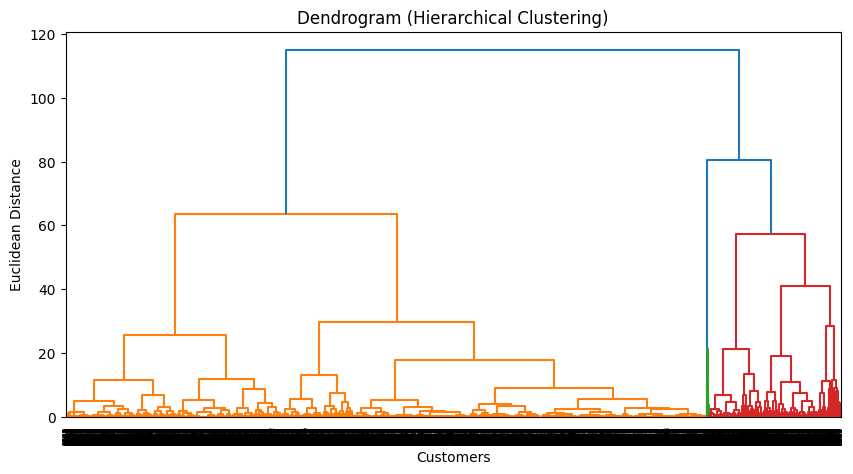

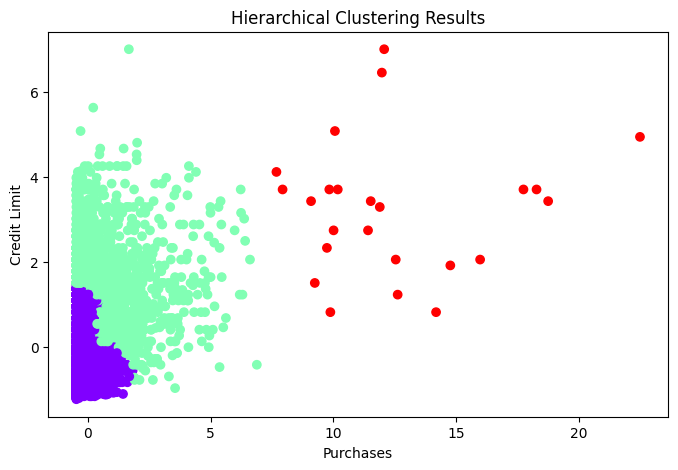

In [4]:
# Select 2 features for visualization
features = df_scaled[['PURCHASES', 'CREDIT_LIMIT']]

# Dendrogram
plt.figure(figsize=(10, 5))
dendrogram = sch.dendrogram(sch.linkage(features, method='ward'))
plt.title('Dendrogram (Hierarchical Clustering)')
plt.xlabel('Customers')
plt.ylabel('Euclidean Distance')
plt.show()

# Apply Agglomerative Clustering
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(features)

# Plot clusters
plt.figure(figsize=(8, 5))
plt.scatter(features['PURCHASES'], features['CREDIT_LIMIT'], c=hc_labels, cmap='rainbow')
plt.title("Hierarchical Clustering Results")
plt.xlabel("Purchases")
plt.ylabel("Credit Limit")
plt.show()


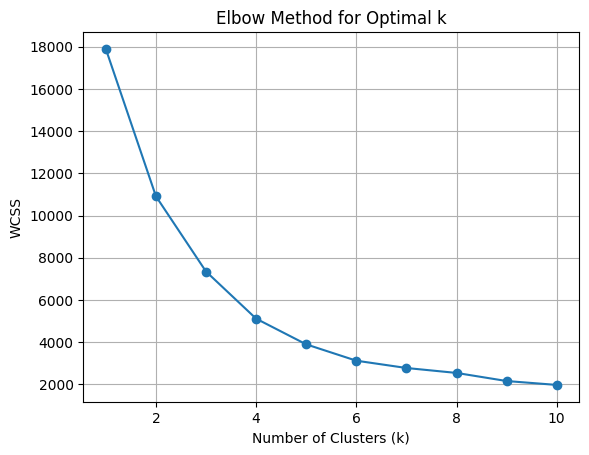

In [5]:
# Determine the best k using Elbow method
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


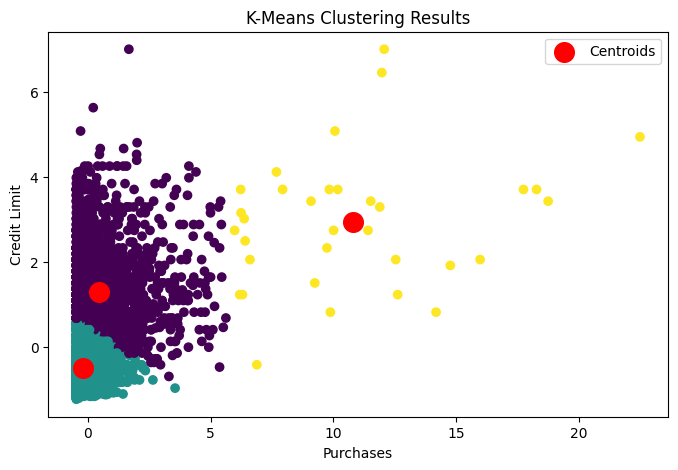

In [6]:
# Let's assume optimal k is 3 based on elbow
kmeans = KMeans(n_clusters=3, random_state=42)
k_labels = kmeans.fit_predict(features)

# Plot clusters
plt.figure(figsize=(8, 5))
plt.scatter(features['PURCHASES'], features['CREDIT_LIMIT'], c=k_labels, cmap='viridis')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=200, c='red', label='Centroids')
plt.title("K-Means Clustering Results")
plt.xlabel("Purchases")
plt.ylabel("Credit Limit")
plt.legend()
plt.show()


Interpretation:

I’ve successfully segmented customers into different groups based on spending (PURCHASES) and credit exposure (CREDIT_LIMIT).

These clusters can help define targeted marketing strategies, such as offering premium services to high-purchase, high-credit-limit customers, or budgeting tools for low-purchase users.